In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [61]:
df = pd.read_csv("customers_data.csv")
df.shape
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data preprocessing

In [62]:
#handling missing values

imputer = SimpleImputer(strategy = "mean")
df[["Income"]] = imputer.fit_transform(df[["Income"]])

# feature engineering

In [63]:
#1 converting dates into meaningfull data

#Age feature
df["Age"] = 2026-df["Year_Birth"]

#cutomer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_tenure_days"] = (reference_date-df["Dt_Customer"]).dt.days
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    2240 non-null   int64         
 1   Year_Birth            2240 non-null   int64         
 2   Education             2240 non-null   object        
 3   Marital_Status        2240 non-null   object        
 4   Income                2240 non-null   float64       
 5   Kidhome               2240 non-null   int64         
 6   Teenhome              2240 non-null   int64         
 7   Dt_Customer           2240 non-null   datetime64[ns]
 8   Recency               2240 non-null   int64         
 9   MntWines              2240 non-null   int64         
 10  MntFruits             2240 non-null   int64         
 11  MntMeatProducts       2240 non-null   int64         
 12  MntFishProducts       2240 non-null   int64         
 13  MntSweetProducts  

In [64]:
#total spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

#total number of kids
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,59,381,1341,1
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,2,5,7,0,0,80,19,444,3
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,0,45,155,1241,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,70,156,843,1


In [65]:
# education
df["Education"].value_counts()
#we will modify education in undergraduate, graduate, post_graduate
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Post_Graduate",
    "PhD" : "Post_Graduate"
})
df["Education"].value_counts()

#marital status
df["Marital_Status"].value_counts()
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Alone" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})

# Drop columns

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    2240 non-null   int64         
 1   Year_Birth            2240 non-null   int64         
 2   Education             2240 non-null   object        
 3   Marital_Status        2240 non-null   object        
 4   Income                2240 non-null   float64       
 5   Kidhome               2240 non-null   int64         
 6   Teenhome              2240 non-null   int64         
 7   Dt_Customer           2240 non-null   datetime64[ns]
 8   Recency               2240 non-null   int64         
 9   MntWines              2240 non-null   int64         
 10  MntFruits             2240 non-null   int64         
 11  MntMeatProducts       2240 non-null   int64         
 12  MntFishProducts       2240 non-null   int64         
 13  MntSweetProducts  

In [67]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns = cols_to_drop)
df_cleaned.shape
df_cleaned

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Post_Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner
2236,Post_Graduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone
2238,Post_Graduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner


# handling outliers

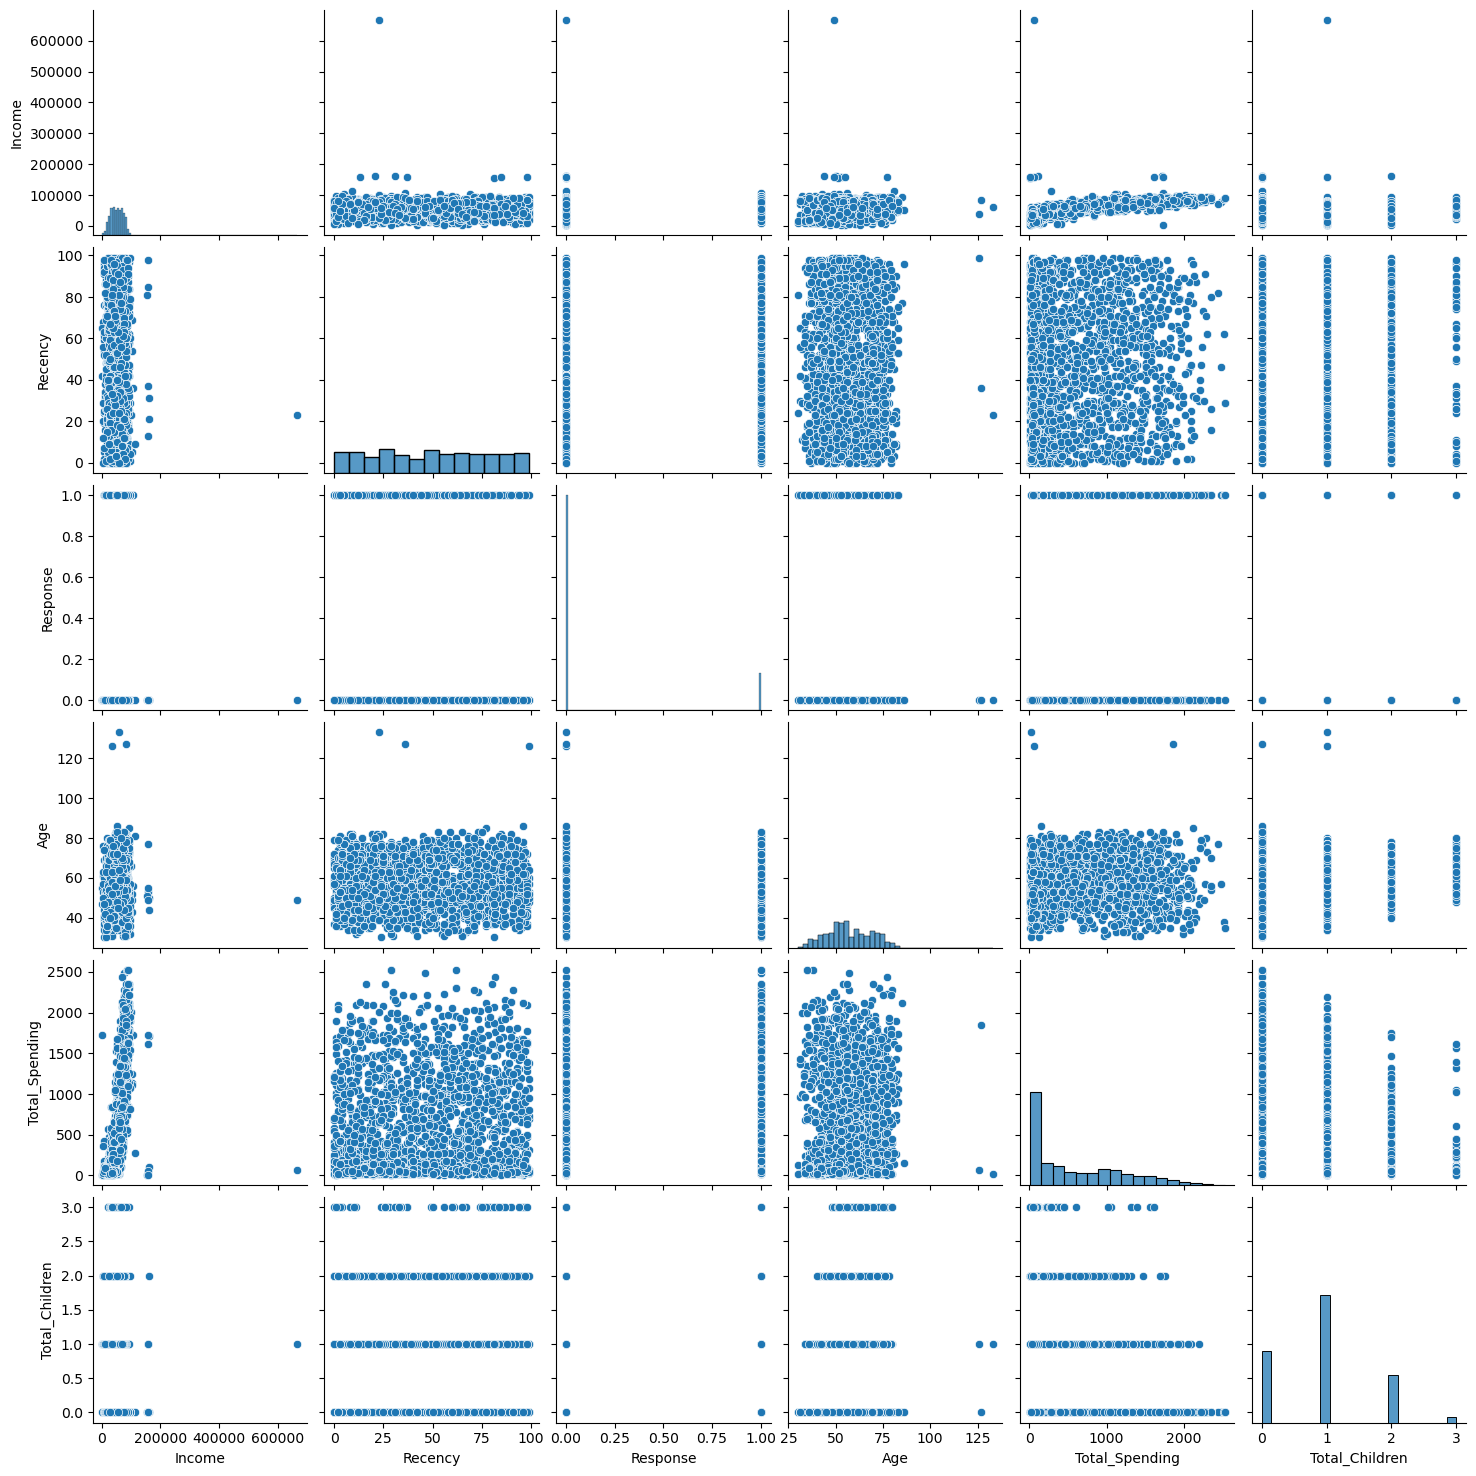

In [69]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

#relative plots of some features- pair plots
sns.pairplot(df_cleaned[cols])

In [70]:
# remove the outliers
print(f"data size with outliers {len(df_cleaned)}")

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print(f"data size without outliers {len(df_cleaned)}")

data size with outliers 2240
data size without outliers 2236


# Heatmap

<Axes: >

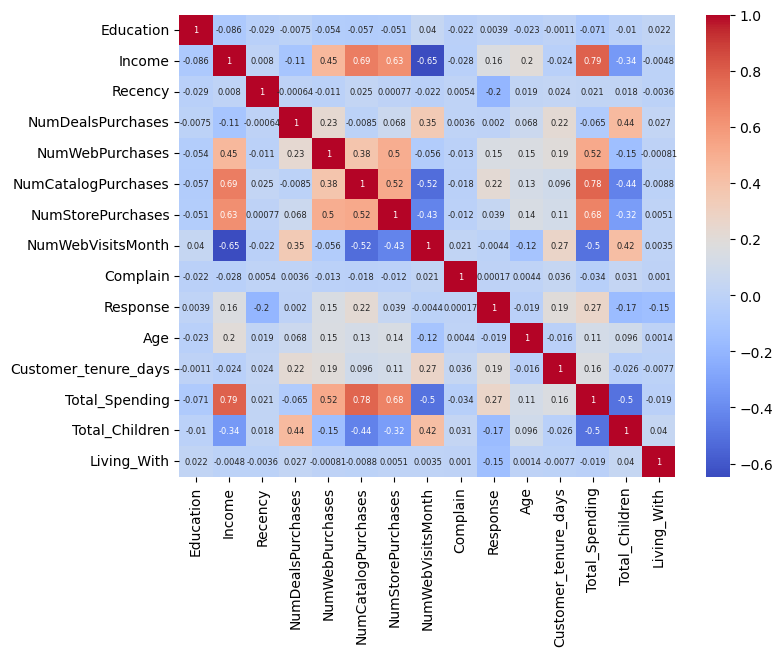

In [75]:
corr = df_cleaned.corr(numeric_only = True)
plt.figure(figsize = (8,6))
sns.heatmap(corr,annot_kws = {"size" : 6}, annot = True, cmap = "coolwarm")

In [ ]:
# insights we get from heatmap is 
# 0.79 income-total_spending
# 0.69 income-catalog spending
# 0.63 income-store purchase
# -0.65 income-website visits
# 0.78 spending-catalog purchase
# 0.78 spending-store purchase

# one hot encoding

In [83]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)
enc_df.head()
enc_df = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis = 1)
enc_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Education_0,Education_1,Education_2,Living_With_0,Living_With_1
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling the data

In [84]:
scaler = StandardScaler()
enc_df_scaled = scaler.fit_transform(enc_df)

# visualizing the data

Text(0.5, 0.92, '3D projection')

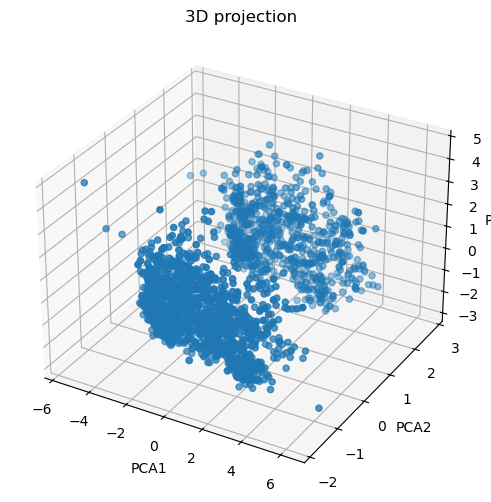

In [97]:
# 2D visualization
from sklearn.decomposition import PCA
pca = PCA(
    n_components = 3,
    
)
X_pca = pca.fit_transform(enc_df_scaled)
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

In [90]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

# Analyse k value

In [99]:
# elbow method
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [100]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
optimal_val = knee.elbow

In [102]:
print(f"optimal k value is {optimal_val}")

optimal k value is 4


Text(0, 0.5, 'WCSS')

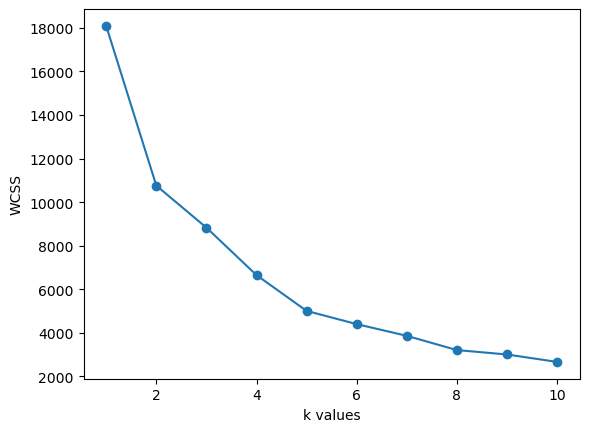

In [104]:
#plot 
plt.plot(range(1,11), wcss, marker = "o")
plt.xlabel("k values")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

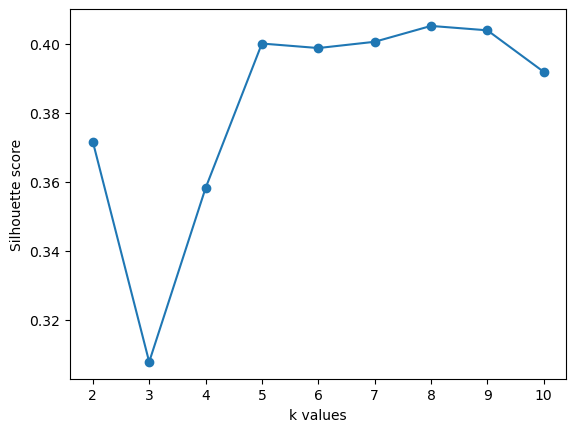

In [108]:
#2 silhouette score

from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

#plot
plt.plot(range(2,11), scores, marker = "o")
plt.xlabel("k values")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'scores')

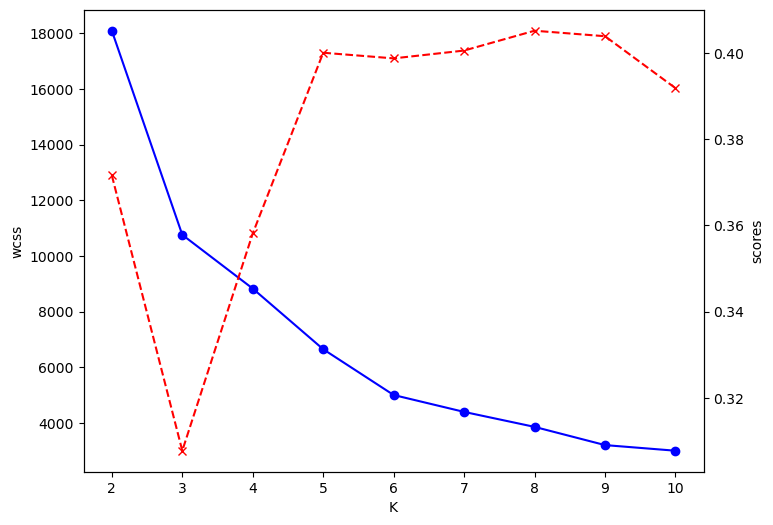

In [114]:
# combined plot
k_range = range(2,11)
fig, ax1 = plt.subplots(figsize = (8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker = "o", color = "blue" )
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker = "x", color = "red", linestyle = "--")
ax2.set_xlabel("K")
ax2.set_ylabel("scores")

# clustering

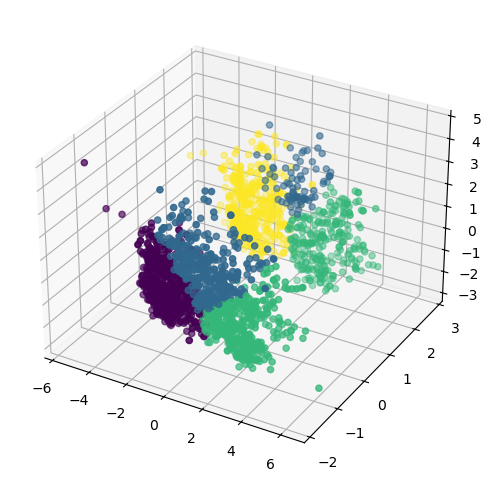

In [119]:
# k_means 
kmeans = KMeans(n_clusters = 4, random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_kmeans)

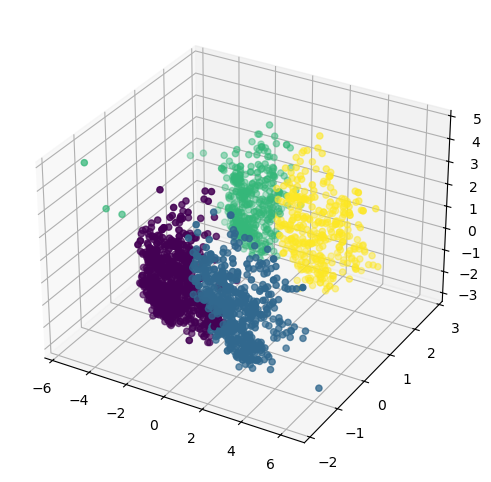

In [121]:
# agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
agg_labels = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = agg_labels)

# characterization of clusterd

In [127]:
df_cleaned["clusters"] = agg_labels
df_cleaned = df_cleaned.drop("Labels", axis = 1)

<Axes: xlabel='Labels', ylabel='count'>

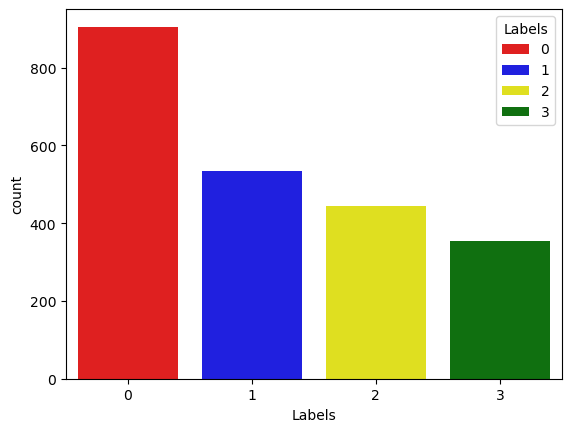

In [123]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x = df_cleaned["Labels"], palette = pal, hue = df_cleaned["Labels"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

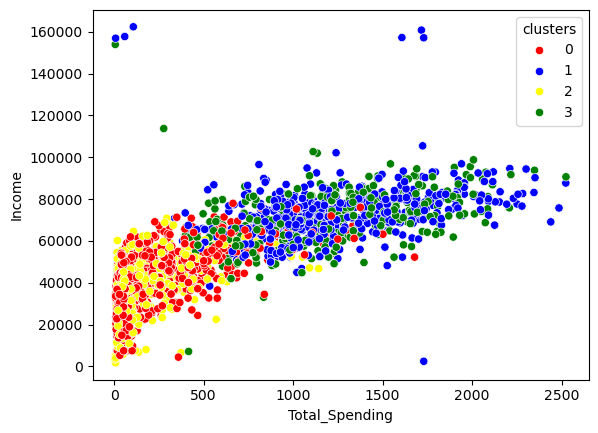

In [129]:
# income & spending patterns

sns.scatterplot(x = df_cleaned["Total_Spending"], y = df_cleaned["Income"], hue = df_cleaned["clusters"], palette = pal)

In [132]:
# cluster summary
cluster_summary = enc_df_scaled.group_by("cluster").mean()
print(cluster_summary)

AttributeError: 'numpy.ndarray' object has no attribute 'group_by'